In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import pickle

from config import *
from SMJP import (
    sparse_mc, get_y_uniform, to_discrete, 
    make_discretized_xi, make_discretized_eta
)
from filter import Filter

In [2]:
theta, y, t = sparse_mc(p0, Lambda, lam, T, get_y_uniform)

dtmc = to_discrete(theta, t, T, ht)
dty = to_discrete(y, t, T, ht)

In [3]:
dxi = make_discretized_xi(t_net_filtering, g, sigma, theta, y, t)
eta = make_discretized_eta(t_net_filtering, h, dtmc, dty, ht, T)

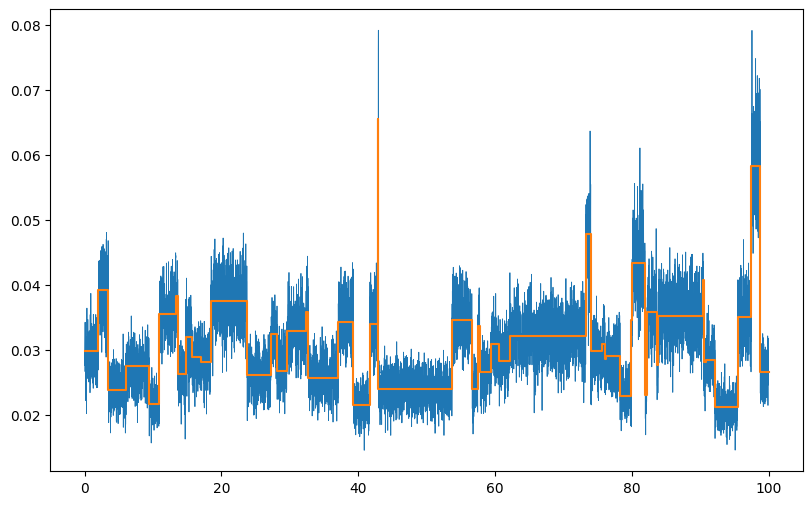

In [4]:
fig, ax = plt.subplots(figsize=(6 * (1 + np.sqrt(5))/2, 6))

ax.plot(t_net_filtering[1:], dxi[1:] / ht1, lw=0.6)
ax.step([0] + list(t), [y[0, 0]] + list(y[:, 0]))

plt.show()

In [5]:
filter = Filter(
    p0[:, np.newaxis] * pi_uniform, 
    pi_uniform, M_net, g, sigma, 
    N, Lambda, ht1, delta
)

est = filter.estimate()
theta_est = [est[0]]
y_est = [est[1]]

for i, obs in enumerate(tqdm(dxi[1:]), start=1):
    filter.update(obs)
    est = filter.estimate()
    if np.any(np.isnan(est[0])) or np.any(np.isnan(est[1])):
        print(f'nan on {i}-th iter')
        break
    theta_est.append(est[0])
    y_est.append(est[1])

  0%|          | 0/9999 [00:00<?, ?it/s]

In [6]:
theta_est = np.array(theta_est)
y_est = np.array(y_est)

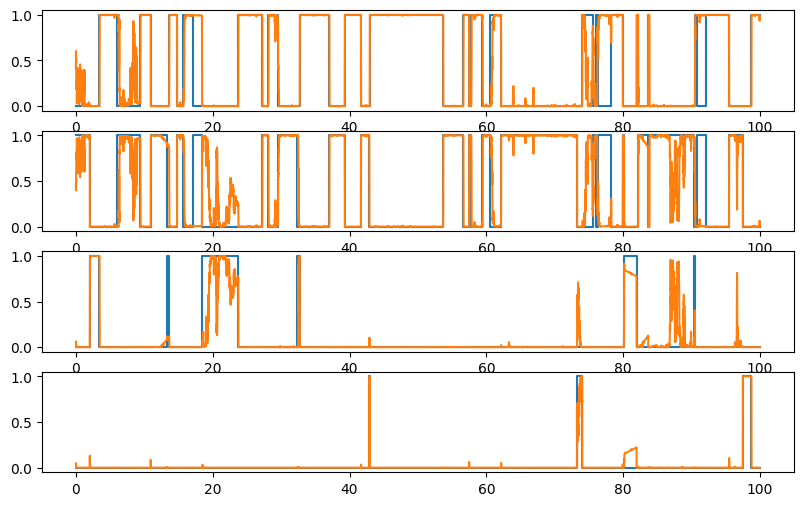

In [7]:
fig, axs = plt.subplots(N, figsize=(6 * (1 + np.sqrt(5))/2, 6))

for i, ax in enumerate(axs):
    ax.step(
        [0] + list(t), 
        [(theta[0] == i)] + list(theta == i)
    )
    ax.plot(
        t_net_filtering[:theta_est.shape[0]],
        theta_est[:, i]
    )

plt.show()

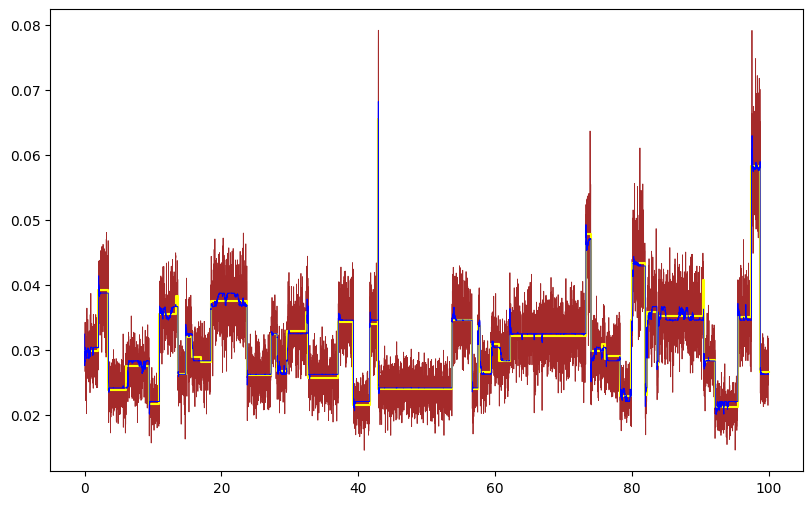

In [18]:
fig, ax = plt.subplots(figsize=(6 * (1 + np.sqrt(5))/2, 6))

ax.plot(t_net_filtering[1:], dxi[1:] / ht1, lw=0.6, color='brown')
ax.step([0] + list(t), [y[0, 0]] + list(y[:, 0]), color='yellow')
ax.plot(t_net_filtering[:y_est.shape[0]], y_est[:, 0], color='b', lw=0.7)

plt.show()

In [9]:
import pickle
with open('saved_path/theta_est.pkl', 'wb') as f:
    pickle.dump(theta_est, f)
with open('saved_path/y_est.pkl', 'wb') as f:
    pickle.dump(y_est, f)
with open('saved_path/theta.pkl', 'wb') as f:
    pickle.dump(theta, f)
with open('saved_path/y.pkl', 'wb') as f:
    pickle.dump(y, f)
with open('saved_path/t.pkl', 'wb') as f:
    pickle.dump(t, f)